# Ranked residual loci: structure and fold (GSE221720)

Periodontitis bone, 4 vs 4 (GSE221720). Tables are a snapshot of one TxNova
run (GENCODE M39). Residual IDs are local to that run.

This notebook does **not** rerun `txnova`. It reads the bundled TSVs and
asks which gated loci look more gene-like, then draws exon maps and the
3Dmol viewer TxNova writes when `coding.fold` is on.

Not a new-gene call. Rank is an inspection order.

```bash
pip install txnova pandas matplotlib
```

**Data.** `docs/tutorials/data/` next to this notebook (`SOURCE.txt`).
Full BAM pipeline: {doc}`../quickstart`. Three tables:
{doc}`../outputs`.


In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HERE = Path("data")
if not (HERE / "gene_rank.tsv").is_file():
    HERE = Path("docs/tutorials/data")

rank = pd.read_csv(HERE / "gene_rank.tsv", sep="\t")
final = pd.read_csv(HERE / "candidates.tsv", sep="\t")
unnamed = pd.read_csv(HERE / "candidates.unnamed.tsv", sep="\t")
print("gene_rank", len(rank), "final", len(final), "unnamed", len(unnamed))

gene_rank 45 final 13 unnamed 32


## Three tables

Same structural gates. Different questions.


In [3]:
summary = pd.DataFrame(
    {
        "table": ["final (treat-specific)", "unnamed (control TPM)", "gene_rank (final ∪ unnamed)"],
        "n": [len(final), len(unnamed), len(rank)],
        "multi_exon": [
            int((final.n_exons >= 3).sum()),
            int((unnamed.n_exons >= 3).sum()),
            int((rank.n_exons >= 3).sum()),
        ],
        "coding_label": [
            final.coding_label.value_counts().to_dict(),
            unnamed.coding_label.value_counts().to_dict(),
            rank.coding_label.value_counts().to_dict(),
        ],
    }
)
summary

,table,n,multi_exon,coding_label
0,final (treat-specific),13,1,"{'coding': 8, 'noncoding': 5}"
1,unnamed (control TPM),32,2,"{'noncoding': 20, 'coding': 12}"
2,gene_rank (final ∪ unnamed),45,3,"{'noncoding': 25, 'coding': 20}"


- **Final** — experimental-group-specific (`low_count` here, not Wald padj).
- **Unnamed** — structure-pass, also transcribed in control. Not induction.
- Shared-splice table is a third file on a full run; this snapshot predates
  that harvest. Rank still includes unnamed, so both-group structure is not
  hidden.


## Which rows look more gene-like

`gene_rank` scores primary chromosome, exon count, BAM junction support,
ORF / hexamer, and penalizes unplaced contigs, unsupported introns, TE
motifs, and intronless copies of known proteins. No Pfam hit on this
snapshot. Use the top of the list first; do not treat score as a gene call.


In [4]:
cols = [
    "gene_rank",
    "locus_id",
    "n_exons",
    "length_nt",
    "nearest_gene_name",
    "nearest_distance_bp",
    "control_max_tpm",
    "treat_median_tpm",
    "junction_support",
    "longest_orf_aa",
    "coding_label",
    "gene_score",
    "gene_flags",
]
rank[cols].head(10)

,gene_rank,locus_id,n_exons,length_nt,nearest_gene_name,nearest_distance_bp,control_max_tpm,treat_median_tpm,junction_support,longest_orf_aa,coding_label,gene_score,gene_flags
0,1,RSDL.2,4,1359,Gm49077,40688,3.146868,2.777545,"2,3,5",46,coding,87.609477,no_orf
1,2,RSDL.4,3,295,Nudc,13494,0.993471,0.885536,"4,3",43,coding,87.130173,no_orf
2,3,RSDL.34,2,597,Gm60499,34234,1.451765,1.233042,3,68,coding,81.934470,NaN
3,4,RSDL.44,2,328,Slc6a6,33521,2.680554,1.203465,3,59,coding,81.475330,NaN
4,5,RSDL.31,2,842,Lgals3bp,15650,0.362792,0.737334,3,60,coding,81.194542,NaN
5,6,RSDL.47,2,458,Gm63857,14800,0.000000,0.677767,3,55,coding,80.920291,NaN
6,7,RSDL.15,2,504,Gm60892,16199,0.000000,1.301527,4,54,coding,80.909515,NaN
7,8,RSDL.51,2,244,Gm25587,112233,0.000000,0.535313,2,66,coding,78.350124,NaN
8,9,RSDL.46,2,341,Tollip,51168,0.000000,0.518810,3,67,coding,78.059007,NaN
9,10,RSDL.80,2,246,Gm66173,45351,1.191357,0.542698,2,56,coding,77.456596,NaN


In [5]:
final_ids = set(final.locus_id.astype(str))
unnamed_ids = set(unnamed.locus_id.astype(str))
head = rank.head(10).copy()
head["in_final"] = head.locus_id.astype(str).isin(final_ids)
head["in_unnamed"] = head.locus_id.astype(str).isin(unnamed_ids)
head[["gene_rank", "locus_id", "n_exons", "in_final", "in_unnamed", "gene_flags", "gene_score"]]

,gene_rank,locus_id,n_exons,in_final,in_unnamed,gene_flags,gene_score
0,1,RSDL.2,4,False,True,no_orf,87.609477
1,2,RSDL.4,3,True,False,no_orf,87.130173
2,3,RSDL.34,2,False,True,NaN,81.934470
3,4,RSDL.44,2,False,True,NaN,81.475330
4,5,RSDL.31,2,True,False,NaN,81.194542
5,6,RSDL.47,2,True,False,NaN,80.920291
6,7,RSDL.15,2,True,False,NaN,80.909515
7,8,RSDL.51,2,True,False,NaN,78.350124
8,9,RSDL.46,2,True,False,NaN,78.059007
9,10,RSDL.80,2,False,True,NaN,77.456596


On this run the top of the rank is mostly unnamed (control TPM still on).
The strongest **treat-specific** multi-exon row is `RSDL.4` (3 exons, near
*Nudc*). `RSDL.2` (4 exons, near *Gm49077*) is the most gene-like
structure-pass locus overall, but both groups transcribe the interval.

Lower-ranked finals such as `RSDL.64` keep a ~30 nt terminal (stub-like)
and a 1 aa ORF — keep them out of the follow-up pile.


## Exon maps


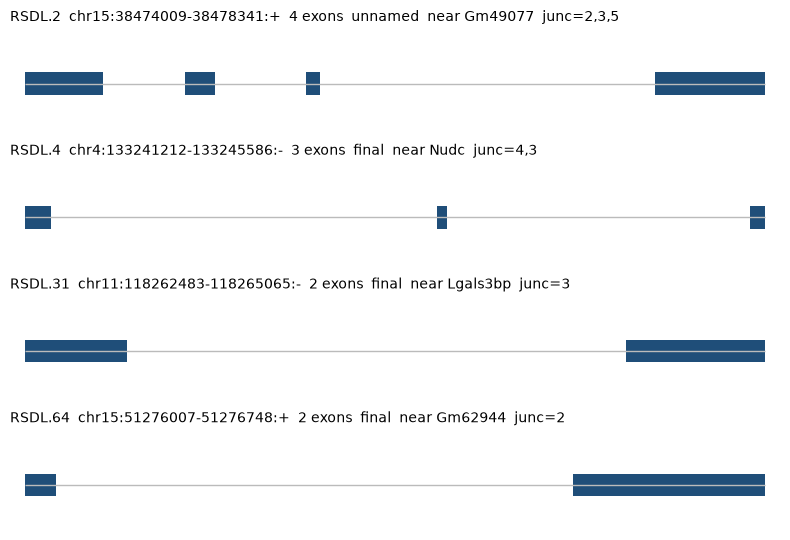

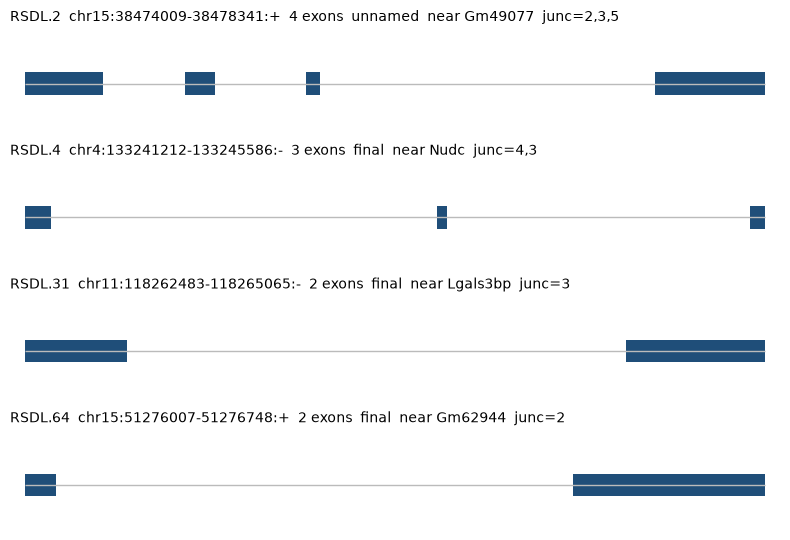

In [6]:
def parse_exons(s):
    out = []
    for part in str(s).split(","):
        a, b = part.split("-")
        out.append((int(a), int(b)))
    return out


def draw_locus(ax, rec, title):
    exons = parse_exons(rec.exon_structure)
    lo, hi = exons[0][0], exons[-1][1]
    span = hi - lo + 1
    ax.hlines(0, 0, 1, color="#bbbbbb", lw=1)
    for s, e in exons:
        x0 = (s - lo) / span
        w = (e - s + 1) / span
        ax.add_patch(plt.Rectangle((x0, -0.25), w, 0.5, color="#1f4e79", lw=0))
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-1.0, 1.2)
    ax.axis("off")
    ax.set_title(title, loc="left", fontsize=10)


pick_ids = ["RSDL.2", "RSDL.4", "RSDL.31", "RSDL.64"]
pool = pd.concat([final, unnamed], ignore_index=True).drop_duplicates("locus_id")
fig, axes = plt.subplots(len(pick_ids), 1, figsize=(8, 5.5), sharex=True)
for ax, lid in zip(axes, pick_ids):
    rec = pool.loc[pool.locus_id == lid].iloc[0]
    where = "final" if lid in final_ids else "unnamed"
    title = (
        f"{lid}  {rec.locus_coord}  {int(rec.n_exons)} exons  "
        f"{where}  near {rec.nearest_gene_name}  "
        f"junc={rec.junction_support}"
    )
    draw_locus(ax, rec, title)
fig.tight_layout()
fig

`RSDL.2` has four exons and three supported junctions — that is why it
ranks first. `RSDL.4` is the only 3-exon treat-specific row. `RSDL.31`
sits 15 kb from *Lgals3bp* with a 60 aa ORF. `RSDL.64` is a short 2-exon
model with a stub terminal.


## Function scores

Hexamer `coding_label` and ORF length are in the tables. Pfam was empty
on this snapshot. phyloP means sit near zero (not conserved like a typical
coding exon). That is expected for a first residual list: rank for
structure, then look by hand.


In [7]:
detail_ids = ["RSDL.2", "RSDL.4", "RSDL.31", "RSDL.15", "RSDL.64"]
rank[rank.locus_id.isin(detail_ids)][
    [
        "gene_rank",
        "locus_id",
        "n_exons",
        "longest_orf_aa",
        "coding_score",
        "coding_label",
        "phylop_mean",
        "pfam_name",
        "gene_flags",
    ]
]

,gene_rank,locus_id,n_exons,longest_orf_aa,coding_score,coding_label,phylop_mean,pfam_name,gene_flags
0,1,RSDL.2,4,46,0.152623,coding,-0.042537,NaN,no_orf
1,2,RSDL.4,3,43,0.036462,coding,-0.030690,NaN,no_orf
4,5,RSDL.31,2,60,0.141191,coding,-0.006274,NaN,NaN
6,7,RSDL.15,2,54,0.261263,coding,-0.050923,NaN,NaN
29,30,RSDL.64,2,1,NaN,noncoding,0.004326,NaN,no_orf


## 3D models (TxNova fold viewer)

When `coding.fold: true`, TxNova writes `fold/<locus>.html` — AlphaFold DB
if the locus is a named protein, ESMFold otherwise. Colour is pLDDT (blue
= confident). Foldseek, if the network step ran, is `fold/function.tsv`.

The public ESMFold endpoint was down when this notebook was frozen, so
the residual ORFs here were not modelled. The view is the same 3Dmol
widget TxNova emits (`txnova.fold.display_structure`), on a packaged
example ORF. Drag to rotate, scroll to zoom. See {doc}`fold_viewer`.

The 3D is **inline HTML/JavaScript** (py3Dmol-style, as in omicverse),
not an iframe, so it stays on the Read the Docs page.

```{raw} html
:file: _fold_embed.html
```


In [ ]:
from pathlib import Path

from txnova.fold import display_structure, mean_ca_b_factor

pdb = Path("data/example.pdb").read_text(encoding="utf-8")
display_structure(
    title="example ORF",
    pdb_text=pdb,
    source="esmfold",
    mean_plddt=mean_ca_b_factor(pdb),
    note="Packaged example (not a GSE221720 residual).",
    viewer_id="notebook_example_orf",
)

## What to follow up

1. `RSDL.4` — only treat-specific 3-exon model; junction support on both
   introns; near *Nudc* but 13 kb away.
2. `RSDL.2` — best gene-like structure, both groups; check whether it is
   a real unannotated locus or a missed annotation hole.
3. Skip stub terminals (`RSDL.64`) and one-off 2-exon models with no ORF.

Clone / RACE those two first. Do not call them genes from this table.
